# 04 · Interpolation: reading between the lines of a table

**Problem.** Property tables list the vapour pressure of water every 10 °C. We need it at
35.4 °C, and at many temperatures for a simulation. The "true" values here come from the Antoine
equation for water, $\log_{10} p[\text{mmHg}] = 8.07131 - 1730.63/(233.426 + T[°C])$ (valid 1-100 °C),
so every interpolation error can be measured exactly.

**What you will learn**

- interpolate tabulated data linearly and with cubic splines
- build a natural cubic spline from its defining equations
- improve accuracy by interpolating a transformed variable
- recognise Runge oscillations and the danger of extrapolation

**Before you start:** notebooks 00 and 03 (tridiagonal systems); polynomials  ·  **Time:** about 45-60 min

Run the cells in order (Shift + Enter). Then change the numbers and run them again - that is how the
ideas sink in.

In [1]:
try:                      # on Google Colab (or anywhere engmath is missing): install it from GitHub
    import engmath
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engmath"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import engmath
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")
from engmath import interpolate

In [2]:
def p_antoine(T):          # kPa
    return 10**(8.07131 - 1730.63/(233.426 + T)) * 0.133322

T_tab = np.arange(10.0, 101.0, 10.0)
p_tab = p_antoine(T_tab)
for T, p in zip(T_tab, p_tab):
    print(f"{T:5.0f} °C  {p:8.3f} kPa")

   10 °C     1.221 kPa
   20 °C     2.330 kPa
   30 °C     4.232 kPa
   40 °C     7.358 kPa
   50 °C    12.306 kPa
   60 °C    19.870 kPa
   70 °C    31.087 kPa
   80 °C    47.267 kPa
   90 °C    70.030 kPa
  100 °C   101.336 kPa


## Linear vs cubic spline at 35.4 °C

In [3]:
T_q = 35.4
p_true = p_antoine(T_q)
p_lin = interpolate.linear(T_tab, p_tab, T_q)
p_spl = interpolate.CubicSpline(T_tab, p_tab)(T_q)
print(f"true   {p_true:.4f} kPa")
print(f"linear {p_lin:.4f} kPa  (error {100*(p_lin/p_true-1):+.2f} %)")
print(f"spline {p_spl:.4f} kPa  (error {100*(p_spl/p_true-1):+.2f} %)")

true   5.7343 kPa
linear 5.9201 kPa  (error +3.24 %)
spline 5.7355 kPa  (error +0.02 %)


## Inside the algorithm: a natural cubic spline
Between neighbouring points the spline is a cubic. Requiring continuous first and second derivatives
gives one equation per interior point for the second derivatives $M_i$:
$$h_{i-1}M_{i-1} + 2(h_{i-1}+h_i)M_i + h_iM_{i+1} = 6\left(\frac{y_{i+1}-y_i}{h_i} - \frac{y_i-y_{i-1}}{h_{i-1}}\right),$$
with $M_0 = M_n = 0$ at the ends (the "natural" spline). Another tridiagonal system (notebook 03):

In [4]:
def spline_by_hand(x, y, xq):
    h = np.diff(x)
    n = len(x)
    A, rhs = np.zeros((n, n)), np.zeros(n)
    A[0, 0] = A[-1, -1] = 1.0                      # natural ends: M_0 = M_n = 0
    for i in range(1, n - 1):
        A[i, i-1], A[i, i], A[i, i+1] = h[i-1], 2 * (h[i-1] + h[i]), h[i]
        rhs[i] = 6 * ((y[i+1] - y[i]) / h[i] - (y[i] - y[i-1]) / h[i-1])
    M = np.linalg.solve(A, rhs)
    i = np.clip(np.searchsorted(x, xq) - 1, 0, n - 2)   # interval containing each query point
    a, b, hi = x[i+1] - xq, xq - x[i], h[i]
    return ((M[i] * a**3 + M[i+1] * b**3) / (6 * hi)
            + (y[i] / hi - M[i] * hi / 6) * a + (y[i+1] / hi - M[i+1] * hi / 6) * b)

print(f"by hand {float(spline_by_hand(T_tab, p_tab, T_q)):.6f} kPa,  library {float(p_spl):.6f} kPa")

by hand 5.735489 kPa,  library 5.735489 kPa


Linear interpolation always *overestimates* a convex curve like this one (the chord lies above the
curve). The cubic spline is far better.

## A better idea: interpolate a smoother quantity
Vapour pressure is nearly exponential in temperature, so $\ln p$ is almost linear in $T$ (and even
more so in $1/T$ - the Clausius-Clapeyron equation). Interpolating the smoother quantity and
transforming back is a powerful trick.

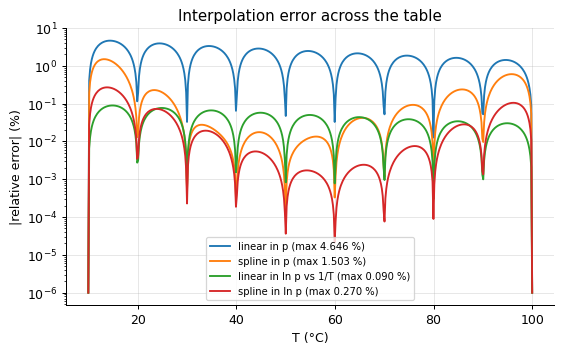

In [5]:
T_fine = np.linspace(10, 100, 500)
p_fine = p_antoine(T_fine)
methods = {
    "linear in p": interpolate.linear(T_tab, p_tab, T_fine),
    "spline in p": interpolate.CubicSpline(T_tab, p_tab)(T_fine),
    "linear in ln p vs 1/T": np.exp(interpolate.linear(1/(T_tab[::-1]+273.15), np.log(p_tab[::-1]), 1/(T_fine+273.15))),
    "spline in ln p": np.exp(interpolate.CubicSpline(T_tab, np.log(p_tab))(T_fine)),
}
fig, ax = plt.subplots()
for name, p in methods.items():
    err = 100*np.abs(p/p_fine - 1)
    ax.semilogy(T_fine, np.maximum(err, 1e-6), label=f"{name} (max {err.max():.3f} %)")
ax.set(xlabel="T (°C)", ylabel="|relative error| (%)", title="Interpolation error across the table")
ax.legend(fontsize=8); plt.show()

Choosing *what* to interpolate matters as much as choosing the method. The spline of $\ln p$ is about
six times more accurate than the spline of $p$ - and even *linear* interpolation of $\ln p$ against
$1/T$, the form suggested by the Clausius-Clapeyron equation, beats both. A little physics beats a
higher polynomial degree.

## A warning: high-degree polynomials oscillate (Runge's phenomenon)
Passing one polynomial through many equally spaced points is tempting and wrong:

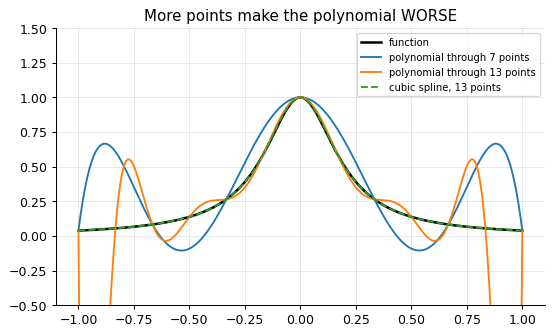

In [6]:
f = lambda x: 1/(1 + 25*x**2)
x_fine = np.linspace(-1, 1, 400)
fig, ax = plt.subplots()
ax.plot(x_fine, f(x_fine), "k", lw=2, label="function")
for n in (7, 13):
    xn = np.linspace(-1, 1, n)
    ax.plot(x_fine, interpolate.lagrange(xn, f(xn), x_fine), label=f"polynomial through {n} points")
xn = np.linspace(-1, 1, 13)
ax.plot(x_fine, interpolate.CubicSpline(xn, f(xn))(x_fine), "--", label="cubic spline, 13 points")
ax.set_ylim(-0.5, 1.5); ax.legend(fontsize=8); ax.set_title("More points make the polynomial WORSE"); plt.show()

## And a second warning: never extrapolate silently
`engmath.interpolate.linear` refuses by default:

In [7]:
try:
    interpolate.linear(T_tab, p_tab, 120.0)
except ValueError as e:
    print("ValueError:", e)

ValueError: Query points outside the data range; pass extrapolate=True if intended.


## Exercises
1. Repeat the error study with the table every 20 °C. How does the maximum error of each method
   scale with the spacing? (Theory: linear $\propto h^2$, cubic spline $\propto h^4$.)
2. Use a spline of $\ln p$ against $T$ to find the boiling temperature at 50 kPa (combine with a
   root finder from notebook 02). Compare with the Antoine equation solved directly.
3. Replace the equally spaced points in the Runge example by Chebyshev points
   $x_j = \cos(j\pi/n)$. What happens to the polynomial?
4. **Implement it yourself:** turn `spline_by_hand` into a *clamped* spline with prescribed end slopes $y'_0$ and $y'_n$ (only the first and last rows of the system change - derive them). Use slopes from the Antoine equation: does the error near the ends of the table fall?